# Large Maze Ellipsoids Diffuser — Training with DeepSet Conditioning + CFG

Trains a VE-SDE score model on the `custom/largemaze_ellipsoids-v1` Minari dataset.  
The model conditions on:
- Start and goal positions
- A **DeepSet-encoded set of up to 5 axis-aligned superellipsoid obstacles** (cx, cy, a, b)

Training uses **Classifier-Free Guidance (CFG)** dropout: with probability `P_UNCOND`,
the ellipsoid conditioning is zeroed out so the model learns both conditional and
unconditional distributions simultaneously.

Sampling uses `dpm_solver_1_cfg_sample` with `guidance_scale` controlling how
strongly the model conditions on the obstacle set.

## 1. Parameters

In [1]:
# ---- Dataset ----
DATASET_ID      = "custom/largemaze_ellipsoids-v1"
LOCAL_DATA_PATH = "../Diffuser/TrajectoryDatasetGeneration/data"  # relative to this notebook
MAX_ELLIPSOIDS  = 5   # fixed set size; missing ellipsoids are padded with zeros

# ---- Model ----
UNET_INPUT_DIM         = 32
DIM_MULTS              = (1, 2, 4)
ELLIPSOID_HIDDEN_DIM   = 128
ELLIPSOID_OUTPUT_DIM   = 256

# ---- VE noise schedule ----
SIGMA_MIN = 0.01
SIGMA_MAX = 10.0
N_LEVELS  = 1000

# ---- CFG ----
P_UNCOND       = 0.1   # probability of dropping ellipsoid conditioning during training
GUIDANCE_SCALE = 3.0   # CFG weight at inference (1.0 = conditional only)

# ---- Training ----
BATCH_SIZE       = 128
LR               = 3e-4
TOTAL_STEPS      = 100_000
EMA_DECAY        = 0.995
EMA_START_STEP   = 1_000
EMA_UPDATE_EVERY = 10

# ---- Sampling ----
N_SAMPLE_STEPS = 25

# ---- Logging ----
LOG_EVERY     = 500
PREVIEW_EVERY = 500
SAVE_EVERY    = 10_000

## 2. Imports

In [2]:
import sys, os, copy, time
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import minari

# EllipsoidalCBFSampling/ is the cwd; its parent (SDPMSP_Clone/) must be on path
PROJECT_ROOT = os.path.dirname(os.getcwd())   # SDPMSP_Clone/
NOTEBOOK_DIR = os.getcwd()                    # EllipsoidalCBFSampling/

for p in [PROJECT_ROOT, NOTEBOOK_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from EllipsoidalCBFSampling.models.score_net_ellipsoids import TemporalUnet
from EllipsoidalCBFSampling.models.ve_diffusion_ellipsoids import VEDiffusion
from EllipsoidalCBFSampling.models.samplers_ellipsoids_cfg import dpm_solver_1_cfg_sample

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cpu


## 3. Dataset

In [3]:
class EllipsoidsMinariDataset(Dataset):
    """
    Wraps the `custom/largemaze_ellipsoids-v1` Minari dataset.

    Each item returns:
        traj       : [T_steps, 2]  float32  — x,y waypoints, normalised to [-1, 1]
        ellipsoids : [MAX_ELLIPSOIDS, 4]  float32  — (cx, cy, a, b); zeros for absent ones

    Normalisation uses per-dim min/max computed from the full dataset on first load.
    """

    def __init__(self, dataset_id, local_data_path, max_ellipsoids=5, T_steps=None):
        os.environ['MINARI_DATASETS_PATH'] = os.path.abspath(local_data_path)
        ds = minari.load_dataset(dataset_id)

        trajs      = []   # list of np arrays [T, 2]
        ellipsoids = []   # list of np arrays [max_ellipsoids, 4]

        for ep in ds.iterate_episodes():
            obs = ep.observations  # [T, 2] (or [T, 4]); take only x,y
            trajs.append(obs[:, :2].astype(np.float32))

            centers = np.array(ep.infos['ellipsoids_centers'][0], dtype=np.float32)  # [N, 2]
            radii   = np.array(ep.infos['ellipsoids_radii'][0],   dtype=np.float32)  # [N, 2]
            ell     = np.concatenate([centers, radii], axis=-1)   # [N, 4]

            # Pad / truncate to fixed set size
            N = ell.shape[0]
            if N < max_ellipsoids:
                pad = np.zeros((max_ellipsoids - N, 4), dtype=np.float32)
                ell = np.concatenate([ell, pad], axis=0)
            else:
                ell = ell[:max_ellipsoids]

            ellipsoids.append(ell)

        # Determine horizon
        horizon = T_steps if T_steps is not None else trajs[0].shape[0]
        self.horizon = horizon

        # Truncate / pad each trajectory to the fixed horizon
        fixed_trajs = []
        for t in trajs:
            if t.shape[0] >= horizon:
                fixed_trajs.append(t[:horizon])
            else:
                pad_rows = np.repeat(t[-1:], horizon - t.shape[0], axis=0)
                fixed_trajs.append(np.concatenate([t, pad_rows], axis=0))

        all_traj = np.stack(fixed_trajs, axis=0)   # [N_ep, T, 2]

        # Normalise trajectories to [-1, 1]
        self.xy_min = all_traj.reshape(-1, 2).min(axis=0)   # [2]
        self.xy_max = all_traj.reshape(-1, 2).max(axis=0)   # [2]
        xy_range = self.xy_max - self.xy_min
        xy_range[xy_range < 1e-6] = 1.0   # guard against degenerate dims
        self.xy_range = xy_range

        norm_traj = 2.0 * (all_traj - self.xy_min) / self.xy_range - 1.0  # [-1, 1]

        self.trajs      = torch.tensor(norm_traj,            dtype=torch.float32)
        self.ellipsoids = torch.tensor(np.stack(ellipsoids), dtype=torch.float32)

        print(f"EllipsoidsMinariDataset loaded: {len(self)} episodes, "
              f"horizon={self.horizon}, ellipsoids/ep={max_ellipsoids}")
        print(f"  xy_min={self.xy_min}, xy_max={self.xy_max}")

    def __len__(self):
        return len(self.trajs)

    def __getitem__(self, idx):
        return self.trajs[idx], self.ellipsoids[idx]

    def unnormalize(self, x):
        """Map normalised [-1,1] coords back to world coords. x: [..., 2]"""
        xy_min   = torch.tensor(self.xy_min,   dtype=x.dtype, device=x.device)
        xy_range = torch.tensor(self.xy_range, dtype=x.dtype, device=x.device)
        return (x + 1.0) / 2.0 * xy_range + xy_min

    def normalize(self, x):
        """Map world coords to normalised [-1,1]. x: [..., 2]"""
        xy_min   = torch.tensor(self.xy_min,   dtype=x.dtype, device=x.device)
        xy_range = torch.tensor(self.xy_range, dtype=x.dtype, device=x.device)
        return 2.0 * (x - xy_min) / xy_range - 1.0


ds = EllipsoidsMinariDataset(
    DATASET_ID,
    LOCAL_DATA_PATH,
    max_ellipsoids=MAX_ELLIPSOIDS,
)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
T_STEPS = ds.horizon
print(f'T_STEPS={T_STEPS}, batches per epoch={len(dl)}')

EllipsoidsMinariDataset loaded: 6005 episodes, horizon=64, ellipsoids/ep=5
  xy_min=[-4.9339027 -3.437651 ], xy_max=[4.936099  3.4286566]
T_STEPS=64, batches per epoch=46


## 4. Model Setup

In [4]:
score_net = TemporalUnet(
    state_dim=2,
    T_steps=T_STEPS,
    unet_input_dim=UNET_INPUT_DIM,
    dim_mults=DIM_MULTS,
    ellipsoid_hidden_dim=ELLIPSOID_HIDDEN_DIM,
    ellipsoid_output_dim=ELLIPSOID_OUTPUT_DIM,
).to(device)

ve = VEDiffusion(
    model=score_net,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    n_levels=N_LEVELS,
).to(device)

ema_model = copy.deepcopy(score_net).to(device)
for p in ema_model.parameters():
    p.requires_grad_(False)

optimizer = torch.optim.Adam(score_net.parameters(), lr=LR)

n_params = sum(p.numel() for p in score_net.parameters())
print(f'TemporalUnet params: {n_params:,}')

# Sanity check: single forward pass
with torch.no_grad():
    _x  = torch.randn(4, T_STEPS, 2, device=device)
    _s  = torch.ones(4, device=device) * 0.5
    _xs = torch.zeros(4, 2, device=device)
    _xg = torch.ones(4, 2, device=device)
    _el = torch.zeros(4, MAX_ELLIPSOIDS, 4, device=device)
    _out = score_net(_x, _s, _xs, _xg, _el)
    print(f'Forward pass OK: output shape = {tuple(_out.shape)}')

TemporalUnet params: 1,345,878
Forward pass OK: output shape = (4, 64, 2)


## 5. Training + Live Preview

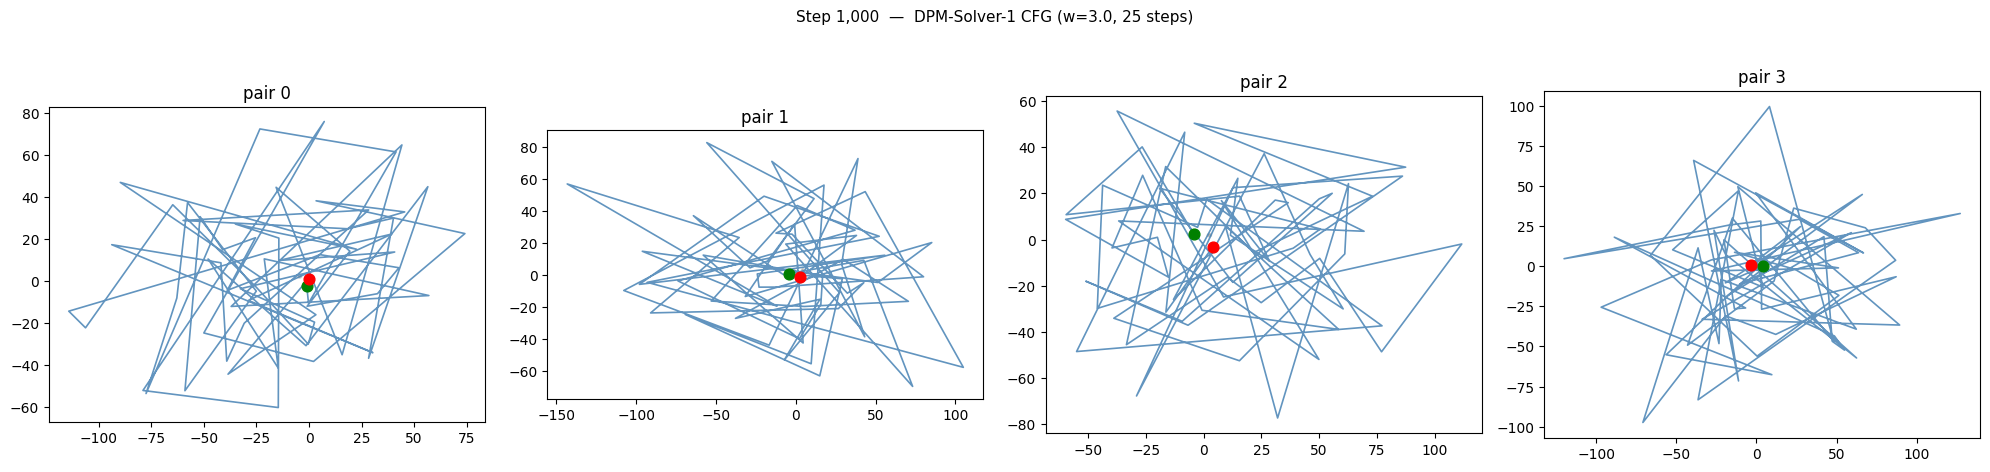

Step:  1001  Loss:  0.06999539583921432
Step:  1002  Loss:  0.07709749788045883
Step:  1003  Loss:  0.07897207140922546
Step:  1004  Loss:  0.06393126398324966
Step:  1005  Loss:  0.07673820108175278
Step:  1006  Loss:  0.06564368307590485
Step:  1007  Loss:  0.06345284730195999
Step:  1008  Loss:  0.0639677494764328
Step:  1009  Loss:  0.0689707100391388
Step:  1010  Loss:  0.07070574164390564
Step:  1011  Loss:  0.06217607110738754
Step:  1012  Loss:  0.06735459715127945
Step:  1013  Loss:  0.07229724526405334
Step:  1014  Loss:  0.07399232685565948
Step:  1015  Loss:  0.07924558967351913
Step:  1016  Loss:  0.06417851895093918
Step:  1017  Loss:  0.06640704721212387
Step:  1018  Loss:  0.07596766948699951
Step:  1019  Loss:  0.07767479121685028
Step:  1020  Loss:  0.07781392335891724
Step:  1021  Loss:  0.07526817917823792
Step:  1022  Loss:  0.05491509288549423
Step:  1023  Loss:  0.06855157762765884
Step:  1024  Loss:  0.06047835946083069
Step:  1025  Loss:  0.07191307097673416
St

KeyboardInterrupt: 

In [5]:
import itertools


def draw_ellipsoid(ax, cx, cy, a, b, color='gray', alpha=0.4, lw=1.5):
    """Draw a degree-4 superellipsoid on ax (approximated as an ellipse patch)."""
    ell = patches.Ellipse(
        (cx, cy), width=2*a, height=2*b,
        linewidth=lw, edgecolor=color, facecolor=color, alpha=alpha,
    )
    ax.add_patch(ell)


# Fixed preview samples
rng_fix   = np.random.default_rng(42)
fix_idx   = rng_fix.choice(len(ds), size=4, replace=False).tolist()
fix_trajs, fix_ells = zip(*[ds[i] for i in fix_idx])
fix_trajs = torch.stack(fix_trajs)   # [4, T, 2]  normalised
fix_ells  = torch.stack(fix_ells)    # [4, 5, 4]
fix_xs    = fix_trajs[:, 0, :].to(device)    # [4, 2]  normalised start
fix_xg    = fix_trajs[:, -1, :].to(device)   # [4, 2]  normalised goal
fix_ells_dev = fix_ells.to(device)


def preview(step):
    ema_model.eval()
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(
        f'Step {step:,}  —  DPM-Solver-1 CFG (w={GUIDANCE_SCALE}, {N_SAMPLE_STEPS} steps)',
        fontsize=11,
    )

    for j, ax in enumerate(axes):
        xs_j  = fix_xs[j:j+1]          # [1, 2]
        xg_j  = fix_xg[j:j+1]          # [1, 2]
        ell_j = fix_ells_dev[j:j+1]    # [1, 5, 4]

        samp = dpm_solver_1_cfg_sample(
            ema_model, ve,
            x_start=xs_j, x_goal=xg_j,
            ellipsoids=ell_j,
            T_steps=T_STEPS,
            n_steps=N_SAMPLE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            device=device,
        )  # [1, T, 2]  normalised

        world  = ds.unnormalize(samp.cpu())      # [1, T, 2]
        xs_w   = ds.unnormalize(xs_j.cpu())      # [1, 2]
        xg_w   = ds.unnormalize(xg_j.cpu())      # [1, 2]

        # Draw ellipsoid obstacles (world coords; fix_ells are already in world coords)
        ell_np = fix_ells[j].numpy()   # [5, 4]
        for row in ell_np:
            cx, cy, a, b = row
            if a > 1e-4 or b > 1e-4:
                draw_ellipsoid(ax, cx, cy, a, b)

        ax.plot(world[0, :, 0], world[0, :, 1], lw=1.2, color='steelblue', alpha=0.85)
        ax.scatter(xs_w[0, 0], xs_w[0, 1], c='green', s=60, zorder=5)
        ax.scatter(xg_w[0, 0], xg_w[0, 1], c='red',   s=60, zorder=5)
        ax.set_title(f'pair {j}')
        ax.set_aspect('equal')

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    score_net.train()


# ---- Training loop ----
loader_iter  = itertools.cycle(dl)
loss_history = []
t0           = time.time()

CKPT_DIR  = os.path.join(NOTEBOOK_DIR, 'checkpoints')
CKPT_NAME = 've_unet_largemaze_ellipsoids_diffuser.pt'
CKPT_PATH = os.path.join(CKPT_DIR, CKPT_NAME)
os.makedirs(CKPT_DIR, exist_ok=True)

for step in range(1, TOTAL_STEPS + 1):
    score_net.train()

    traj, ellipsoids = next(loader_iter)
    traj       = traj.to(device)        # [B, T, 2]
    ellipsoids = ellipsoids.to(device)  # [B, 5, 4]
    xs = traj[:, 0, :]                  # [B, 2]
    xg = traj[:, -1, :]                 # [B, 2]

    loss, info = ve(traj, xs, xg, ellipsoids, p_uncond=P_UNCOND)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # EMA update
    if step >= EMA_START_STEP and step % EMA_UPDATE_EVERY == 0:
        with torch.no_grad():
            for p_ema, p in zip(ema_model.parameters(), score_net.parameters()):
                p_ema.data.mul_(EMA_DECAY).add_(p.data, alpha=1.0 - EMA_DECAY)

    loss_history.append(info['loss'])

    print("Step: ",step, " Loss: ", loss.item())

    if step % LOG_EVERY == 0:
        elapsed = time.time() - t0
        avg = np.mean(loss_history[-LOG_EVERY:])
        print(f'step {step:>7,} | loss {avg:.4f} | sigma_mean {info["sigma_mean"]:.3f} | {elapsed:.0f}s')

    if step % PREVIEW_EVERY == 0:
        clear_output(wait=True)
        preview(step)

    if step % SAVE_EVERY == 0:
        torch.save({
            'step':      step,
            'score_net': score_net.state_dict(),
            'ema_model': ema_model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss_history': loss_history,
            'config': {
                'T_steps':               T_STEPS,
                'unet_input_dim':        UNET_INPUT_DIM,
                'dim_mults':             list(DIM_MULTS),
                'sigma_min':             SIGMA_MIN,
                'sigma_max':             SIGMA_MAX,
                'n_levels':              N_LEVELS,
                'ellipsoid_hidden_dim':  ELLIPSOID_HIDDEN_DIM,
                'ellipsoid_output_dim':  ELLIPSOID_OUTPUT_DIM,
                'max_ellipsoids':        MAX_ELLIPSOIDS,
                'p_uncond':              P_UNCOND,
                'guidance_scale':        GUIDANCE_SCALE,
                'dataset_id':            DATASET_ID,
                'xy_min':                ds.xy_min.tolist(),
                'xy_max':                ds.xy_max.tolist(),
            },
        }, CKPT_PATH)
        print(f'  checkpoint saved → {CKPT_PATH}')

print('Training complete.')

## 6. Checkpoint — Save / Load

In [ ]:
# ---- Save manually (if training was interrupted) ----
torch.save({
    'step':      step,
    'score_net': score_net.state_dict(),
    'ema_model': ema_model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'loss_history': loss_history,
    'config': {
        'T_steps':               T_STEPS,
        'unet_input_dim':        UNET_INPUT_DIM,
        'dim_mults':             list(DIM_MULTS),
        'sigma_min':             SIGMA_MIN,
        'sigma_max':             SIGMA_MAX,
        'n_levels':              N_LEVELS,
        'ellipsoid_hidden_dim':  ELLIPSOID_HIDDEN_DIM,
        'ellipsoid_output_dim':  ELLIPSOID_OUTPUT_DIM,
        'max_ellipsoids':        MAX_ELLIPSOIDS,
        'p_uncond':              P_UNCOND,
        'guidance_scale':        GUIDANCE_SCALE,
        'dataset_id':            DATASET_ID,
        'xy_min':                ds.xy_min.tolist(),
        'xy_max':                ds.xy_max.tolist(),
    },
}, CKPT_PATH)
print('Saved →', CKPT_PATH)

In [ ]:
# ---- Load ----
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg  = ckpt['config']

score_net = TemporalUnet(
    state_dim=2,
    T_steps=cfg['T_steps'],
    unet_input_dim=cfg['unet_input_dim'],
    dim_mults=tuple(cfg['dim_mults']),
    ellipsoid_hidden_dim=cfg['ellipsoid_hidden_dim'],
    ellipsoid_output_dim=cfg['ellipsoid_output_dim'],
).to(device)

ve = VEDiffusion(
    score_net,
    sigma_min=cfg['sigma_min'],
    sigma_max=cfg['sigma_max'],
    n_levels=cfg['n_levels'],
).to(device)

ema_model = copy.deepcopy(score_net).to(device)
score_net.load_state_dict(ckpt['score_net'])
ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()

T_STEPS        = cfg['T_steps']
GUIDANCE_SCALE = cfg.get('guidance_scale', 3.0)
MAX_ELLIPSOIDS = cfg.get('max_ellipsoids', 5)

print(f"Loaded step {ckpt['step']:,}  |  T_steps={T_STEPS}")

## 7. Final Sampling — 2×4 Grid

In [ ]:
ema_model.eval()

rng_eval   = np.random.default_rng(7)
eval_idx   = rng_eval.choice(len(ds), size=8, replace=False)
eval_trajs, eval_ells = zip(*[ds[i] for i in eval_idx])
eval_trajs = torch.stack(eval_trajs)   # [8, T, 2]
eval_ells  = torch.stack(eval_ells)    # [8, 5, 4]
eval_xs    = eval_trajs[:, 0, :].to(device)    # [8, 2]
eval_xg    = eval_trajs[:, -1, :].to(device)   # [8, 2]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f'DPM-Solver-1 CFG  (w={GUIDANCE_SCALE}, {N_SAMPLE_STEPS} steps)  —  largemaze_ellipsoids',
    fontsize=13,
)

for j, ax in enumerate(axes.flat):
    xs_j  = eval_xs[j:j+1]
    xg_j  = eval_xg[j:j+1]
    ell_j = eval_ells[j:j+1].to(device)

    samp = dpm_solver_1_cfg_sample(
        ema_model, ve,
        x_start=xs_j, x_goal=xg_j,
        ellipsoids=ell_j,
        T_steps=T_STEPS,
        n_steps=N_SAMPLE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        device=device,
    )  # [1, T, 2]

    world  = ds.unnormalize(samp.cpu())          # [1, T, 2]
    xs_w   = ds.unnormalize(xs_j.cpu())          # [1, 2]
    xg_w   = ds.unnormalize(xg_j.cpu())          # [1, 2]

    # Draw ellipsoids
    ell_np = eval_ells[j].numpy()   # [5, 4]
    for row in ell_np:
        cx, cy, a, b = row
        if a > 1e-4 or b > 1e-4:
            draw_ellipsoid(ax, cx, cy, a, b)

    ax.plot(world[0, :, 0], world[0, :, 1], lw=1.4, color='steelblue', alpha=0.9)
    ax.scatter(xs_w[0, 0], xs_w[0, 1], c='green', s=60, zorder=6, label='start')
    ax.scatter(xg_w[0, 0], xg_w[0, 1], c='red',   s=60, zorder=6, label='goal')
    ax.set_aspect('equal')
    if j == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Loss Curve

In [ ]:
smooth = np.convolve(loss_history, np.ones(200) / 200, mode='valid')
plt.figure(figsize=(10, 3))
plt.plot(loss_history, alpha=0.2, color='steelblue', linewidth=0.5)
plt.plot(np.arange(len(smooth)) + 100, smooth, color='steelblue', linewidth=1.5)
plt.xlabel('Step')
plt.ylabel('DSM Loss')
plt.title('Training Loss — LargeMaze Ellipsoids Diffuser (CFG)')
plt.tight_layout()
plt.show()